In [13]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import sklearn

In [3]:
df = pd.read_csv('../data/spotify-tracks.csv')

In [4]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


(-0.25, 1.25)

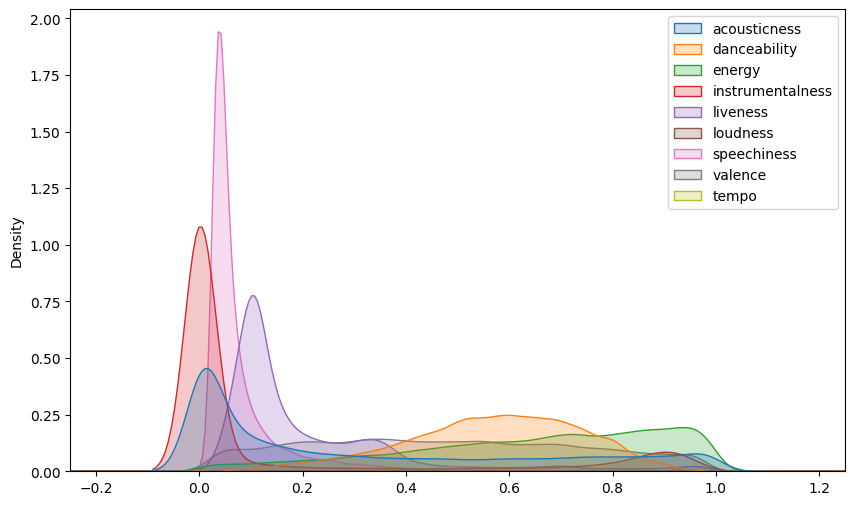

In [8]:
features = [
    "acousticness", "danceability", "energy",
    "instrumentalness", "liveness", "loudness",
    "speechiness", "valence", "tempo"
]


plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[features], fill=True) # for kde plot
plt.xlim(-0.25, 1.25)

array([[<Axes: title={'center': 'acousticness'}>,
        <Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>],
       [<Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'loudness'}>],
       [<Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'valence'}>,
        <Axes: title={'center': 'tempo'}>]], dtype=object)

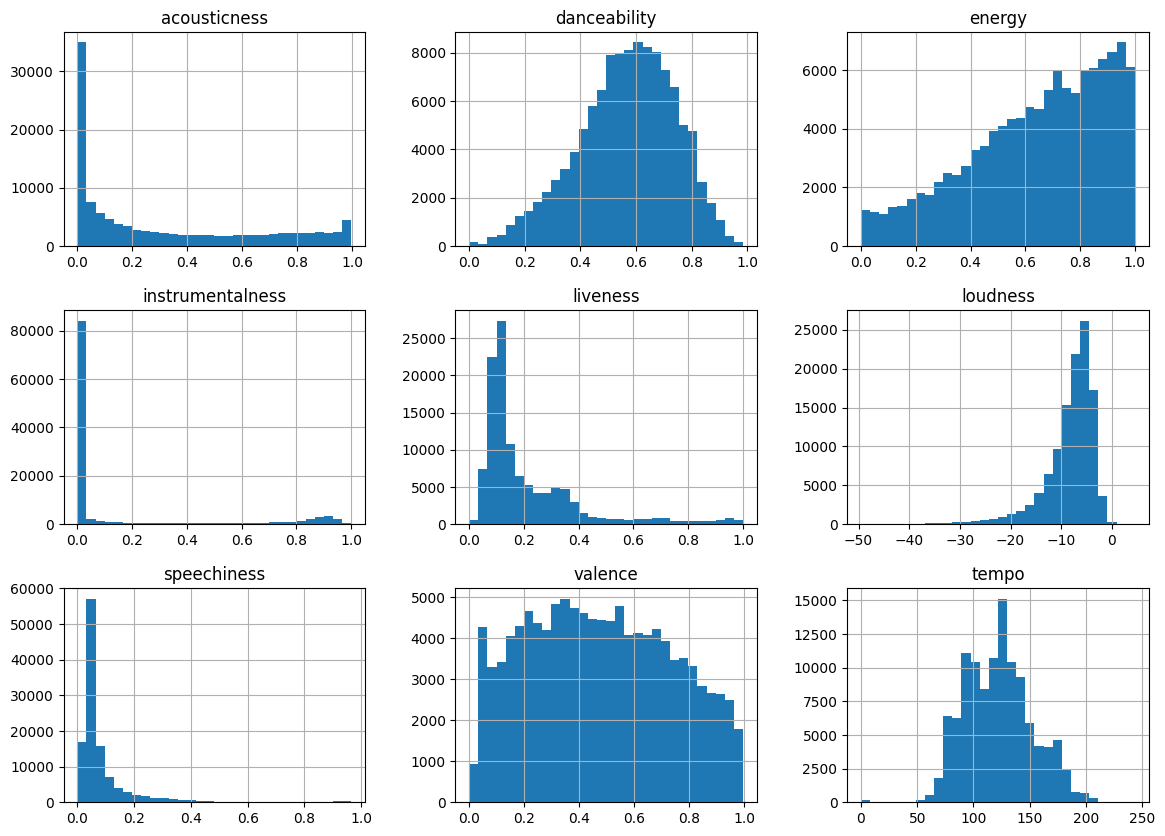

In [9]:
df[features].hist(bins=30, figsize=(14,10))


In [10]:
df[features].corr().round(2)

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo
acousticness,1.00,-0.17,-0.73,0.10,-0.02,-0.59,-0.00,-0.11,-0.21
danceability,-0.17,1.00,0.13,-0.19,-0.13,0.26,0.11,0.48,-0.05
energy,-0.73,0.13,1.00,-0.18,0.18,0.76,0.14,0.26,0.25
instrumentalness,0.10,-0.19,-0.18,1.00,-0.08,-0.43,-0.09,-0.32,-0.05
liveness,-0.02,-0.13,0.18,-0.08,1.00,0.08,0.21,0.02,0.00
loudness,-0.59,0.26,0.76,-0.43,0.08,1.00,0.06,0.28,0.21
speechiness,-0.00,0.11,0.14,-0.09,0.21,0.06,1.00,0.04,0.02
valence,-0.11,0.48,0.26,-0.32,0.02,0.28,0.04,1.00,0.08
tempo,-0.21,-0.05,0.25,-0.05,0.00,0.21,0.02,0.08,1.00


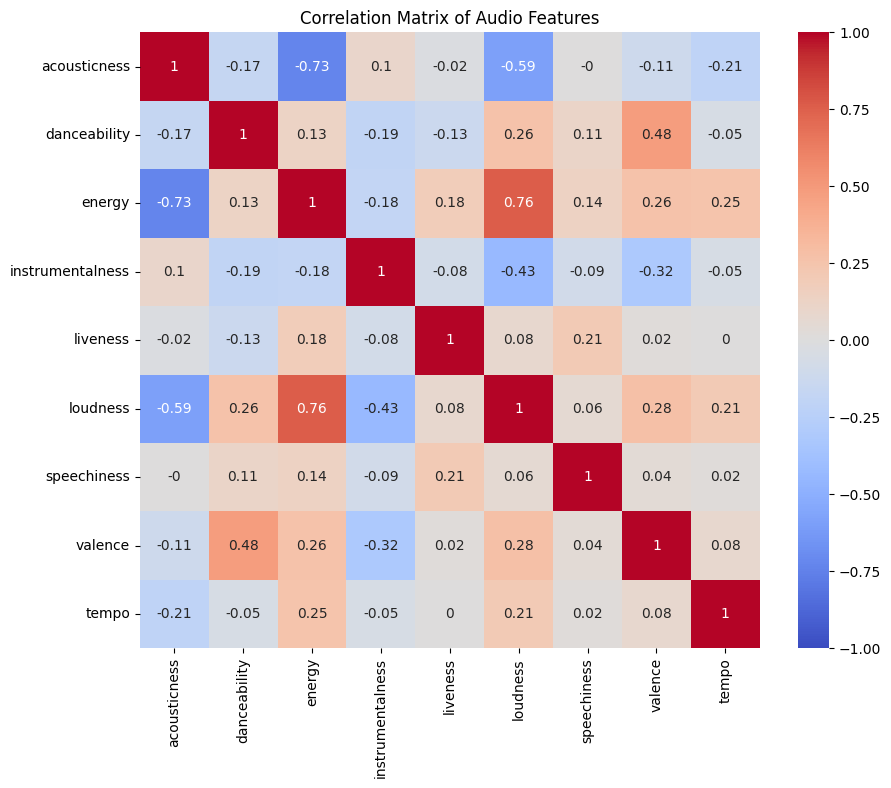

In [11]:
df_corr = df[features].corr().round(2)
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Audio Features")
plt.show()

In [14]:
X = df[features]
# print(X)
# X = X[~pd.isnull(X).any(axis=1)]  # Remove rows with NaN values
X = X.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

# df["pca_1"] = X_reduced[:, 0]
# df["pca_2"] = X_reduced[:, 1]

print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.31928044 0.15850944]
0.47778987900982417


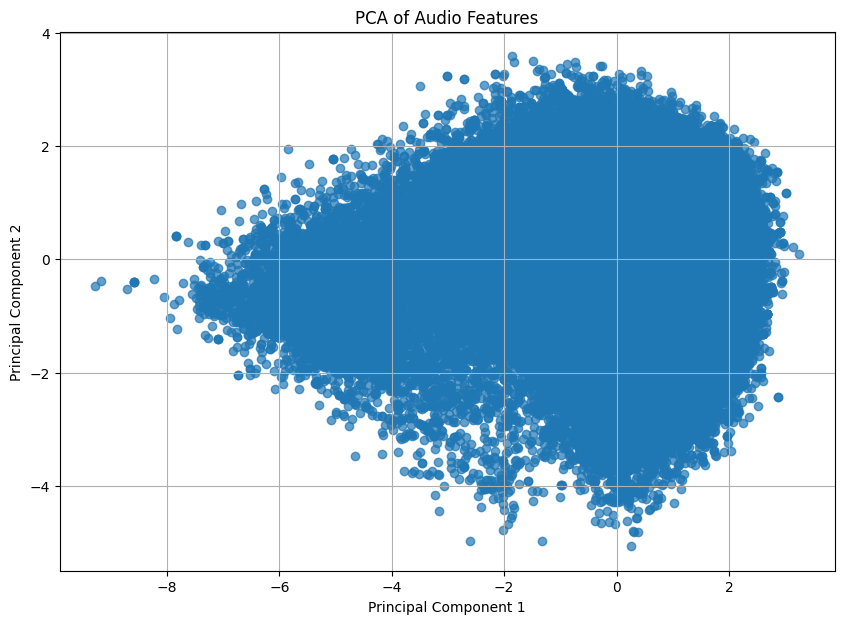

In [15]:

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], alpha =0.7)
plt.title("PCA of Audio Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

In [16]:
model = sklearn.cluster.KMeans(n_clusters=8, random_state=42)
clusters = model.fit_predict(X_scaled)

# plt.figure(figsize=(10, 7))
# plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=clusters, cmap='viridis', alpha=0.5)
# plt.title("K-Means Clustering of Audio Features (PCA Reduced)")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.grid()
# plt.show()


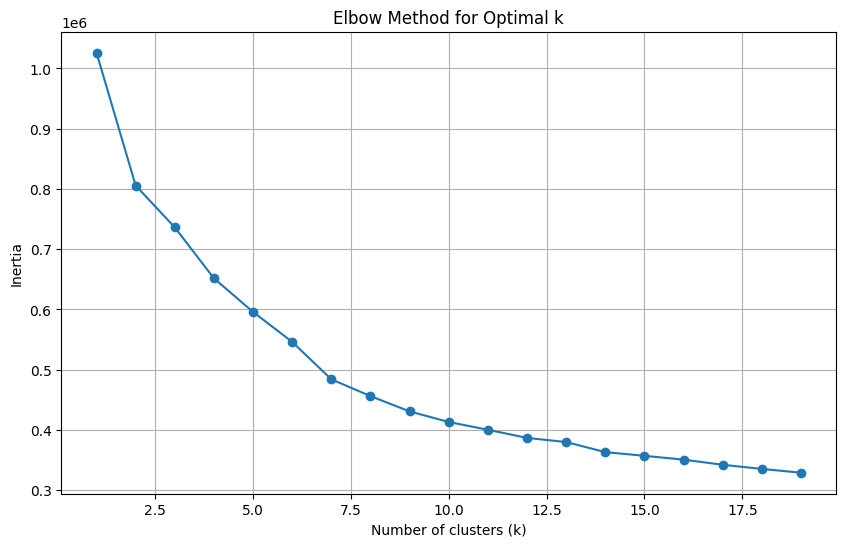

In [17]:
ks = range(1,20)
errors = []

for k in ks:
    model = sklearn.cluster.KMeans(n_clusters=k, random_state=42)
    clusters = model.fit_predict(X_scaled)
    error = model.inertia_
    errors.append(error)

plt.figure(figsize=(10, 6))
plt.plot(ks, errors, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid()

In [18]:
k = 7
model = sklearn.cluster.KMeans(n_clusters=k, random_state=42)
clusters = model.fit_predict(X_scaled)

# plt.figure(figsize=(10, 7))
# plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=clusters, cmap='viridis', alpha=0.5)
# plt.title("K-Means Clustering of Audio Features (PCA Reduced)")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.grid()
# plt.show()


In [20]:
centroids = pd.DataFrame(
    model.cluster_centers_,
    columns=features
)

# unscale so values are human-readable
centroids_unscaled = pd.DataFrame(
    scaler.inverse_transform(centroids),
    columns=features
)

centroids_unscaled.describe()
print(centroids_unscaled)

   acousticness  danceability    energy  instrumentalness  liveness  \
0      0.112311      0.586342  0.740691          0.789419  0.169681   
1      0.865349      0.346026  0.168971          0.784481  0.162532   
2      0.729365      0.575852  0.666409          0.010027  0.643330   
3      0.075294      0.473950  0.814762          0.032714  0.193485   
4      0.285717      0.524165  0.752270          0.066258  0.740295   
5      0.207545      0.704906  0.721869          0.018052  0.163917   
6      0.676966      0.530937  0.377324          0.028591  0.157438   

    loudness  speechiness   valence       tempo  
0  -8.416911     0.071237  0.340189  126.833046  
1 -21.209757     0.050827  0.185284  103.033444  
2 -11.191999     0.830376  0.445064  101.820432  
3  -5.323000     0.084345  0.377236  140.477742  
4  -7.008537     0.087133  0.511301  123.236700  
5  -6.396885     0.092799  0.692139  117.155551  
6 -10.619899     0.053138  0.391893  113.230257  


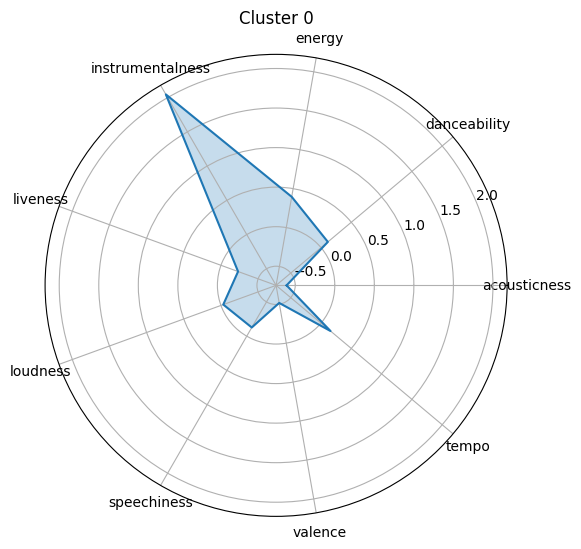

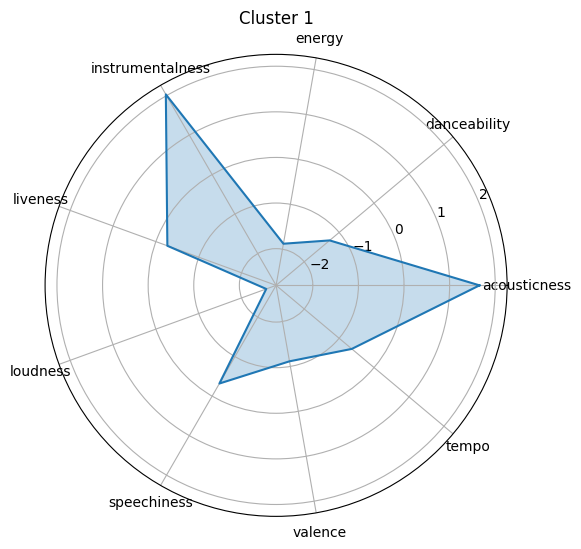

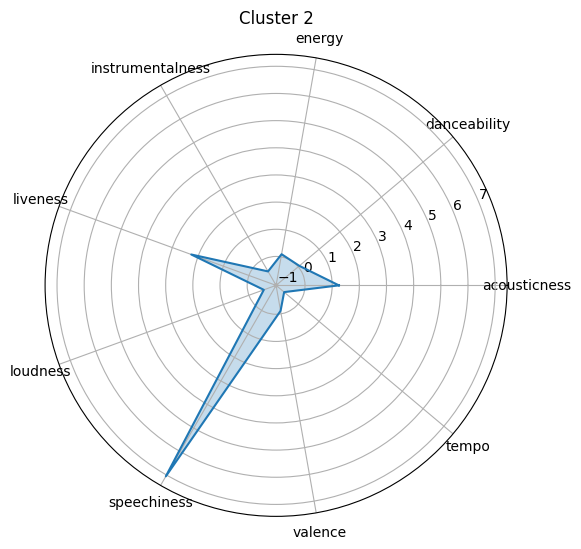

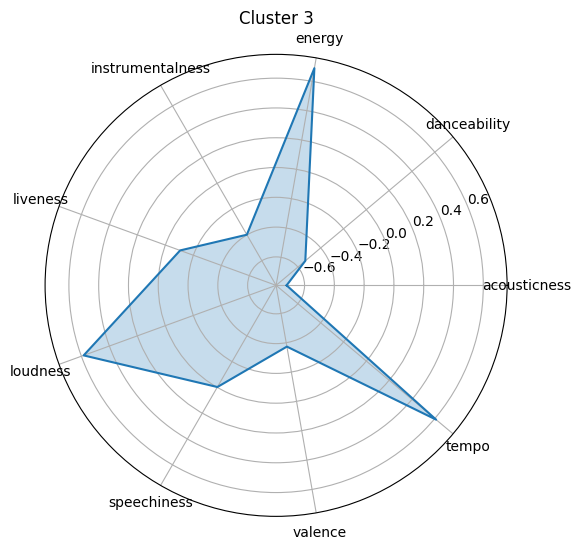

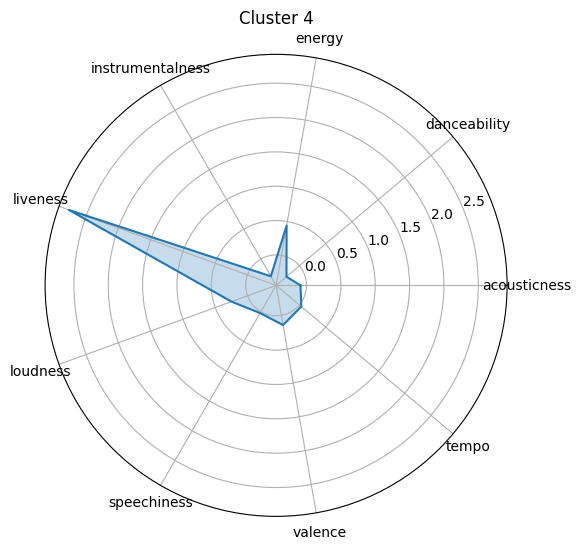

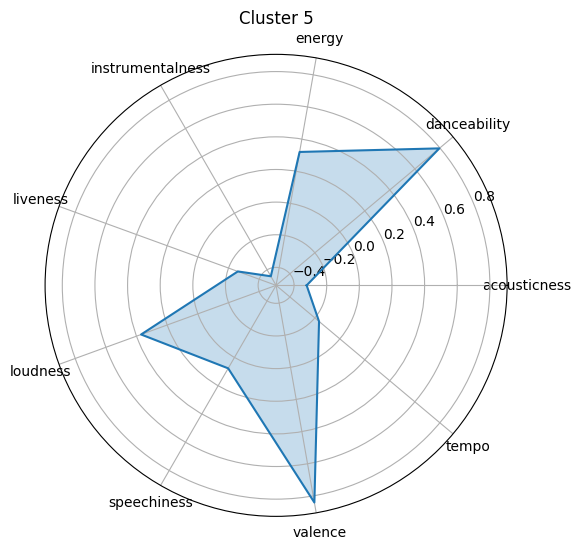

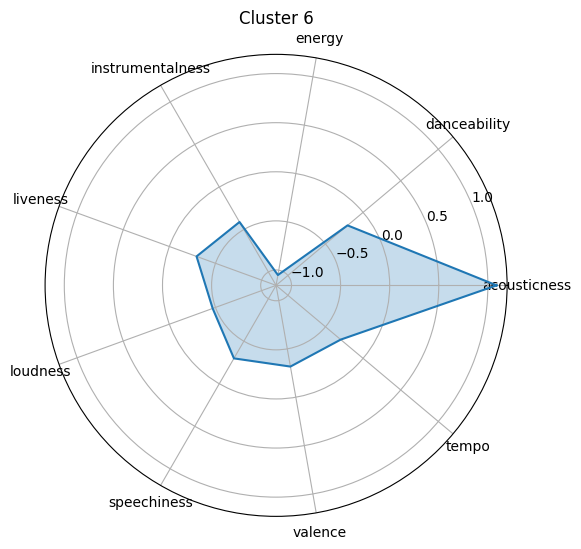

In [21]:
import numpy as np

def radar_plot(row, title):
    values = row.values.tolist()
    values += values[:1]

    angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), features)
    plt.title(title)
    plt.show()

for i in range(k):
    radar_plot(centroids.iloc[i], f"Cluster {i}")